In [14]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt # Visualization

import sklearn.metrics
import statistics
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

file_path = '../Dataset/preprocessed_combined_data_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

df.set_index('Date Time', inplace=True)

display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h
Date Time,,,,,,,,,,,,
3/24/2022 0:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0
3/24/2022 0:15,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0
3/24/2022 0:30,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0
3/24/2022 0:45,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0
3/24/2022 1:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3/22/2023 22:45,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0
3/22/2023 23:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0
3/22/2023 23:15,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0


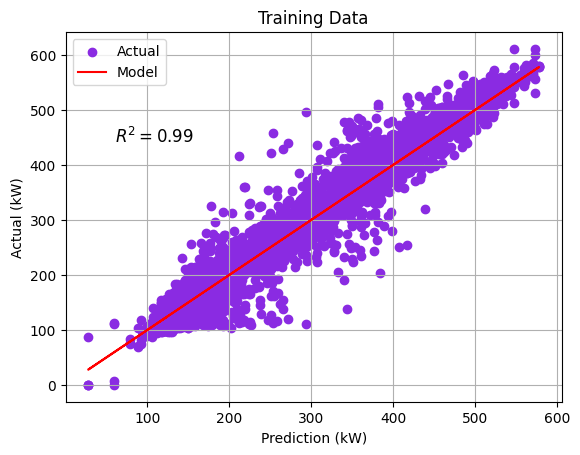

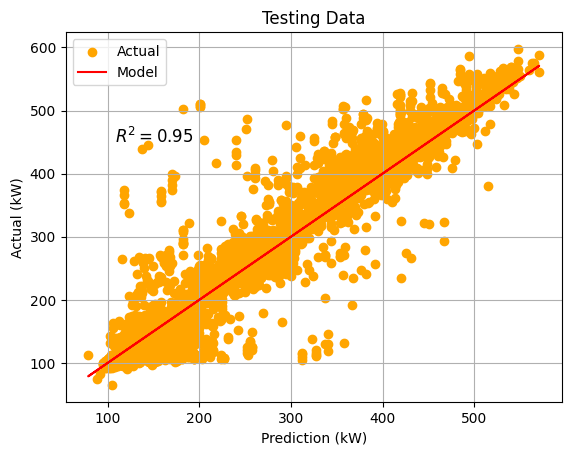

In [15]:
# RF
scaler = StandardScaler()
rf = RandomForestRegressor(random_state=42)

X = df[['Altimeter reading', 'DP Temp (F)', 'DB Temp (F)' , 'Heat_day', 'Cool_day', 'DP_12h','DB_12h', 'DP_24h', 'DB_24h']]
y = df['kW']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

Fit = scaler.fit(X_train)

X_train_scaled = Fit.transform(X_train)
X_test_scaled = Fit.transform(X_test)

rf.fit(X_train_scaled, y_train)
y_predict_train = rf.predict(X_train_scaled)
y_predict_test = rf.predict(X_test_scaled)

# Plot actual and predicted values for training and testing sets
# Train set
fig, ax = plt.subplots()
ax.scatter(y_predict_train,y_train, c='blueviolet', label='Actual')  # Scatter = actual
ax.plot(y_predict_train, y_predict_train, c="red", label='Model')  # line = prediction 
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Training Data')
ax.legend()
ax.grid()

# Add r2 value on plot
r_squared = r2_score(y_train, y_predict_train)
ax.annotate(f'$R^2 = {r_squared:.2f}$', xy=(0.1, 0.7), xycoords='axes fraction', fontsize=12)

# Test set
fig,ax = plt.subplots()
ax.scatter(y_predict_test, y_test, c='orange', label='Actual')
ax.plot(y_predict_test, y_predict_test, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Testing Data')
# Add r2 value on plot
r_squared = r2_score(y_test, y_predict_test)
ax.annotate(f'$R^2 = {r_squared:.2f}$', xy=(0.1, 0.7), xycoords='axes fraction', fontsize=12)
ax.legend()
ax.grid()